In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

from spectrumlab.lines import Line
from spectrumlab.types import Array, Celsius

from spectrumlab_spectral_line.constants import SIGMA, TAU
from spectrumlab_spectral_line.estimators import (
    LineShapeEstimator,
    LineShapeEstimatorConfig,
)

BUFFER = 'Ar'


lines = [
    ('Cs', 455.5275),
    ('Cs', 852.1),
    ('K', 766.490),
]


In [2]:
temperature: Array[Celsius] = np.linspace(1000, 3000, 100)

In [3]:
def estimate(
    element,
    wavelength,
    temperature: Celsius,
) -> float:
    estimator = LineShapeEstimator(
        config=LineShapeEstimatorConfig(
            temperature=temperature + 273.15,
            buffer=BUFFER,
            tau=TAU,
            sigma=SIGMA,
        ),
    )
    shape = estimator.fit(line=Line(element, wavelength))

    return shape.fwhm

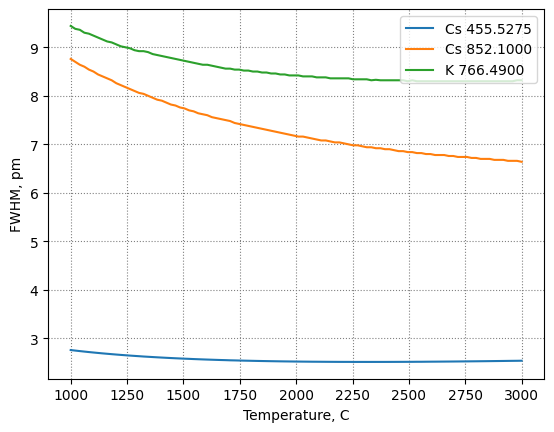

In [4]:
fwhm = {}
for element, wavelength in lines:
    key = '{element} {wavelength:.4f}'.format(
        element=element,
        wavelength=wavelength,
    )
    value = np.array(list(map(partial(estimate, element, wavelength), temperature)))

    fwhm[key] = value

    plt.plot(
        temperature, value,
        label=key,
    )

plt.xlabel('Temperature, C')
plt.ylabel('FWHM, pm')

plt.grid(
    color='grey', linestyle=':',
)
plt.legend(
    loc='upper right'
)
plt.show()

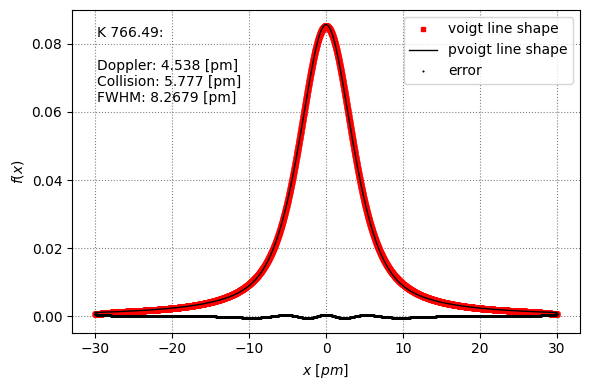

In [5]:
estimator = LineShapeEstimator(
    config=LineShapeEstimatorConfig(
        temperature=2400 + 273.15,
        buffer='Ar',
        tau=TAU,
        sigma=SIGMA,
    ),
)
shape = estimator.fit(
    line=Line(element, wavelength),
    dx=.01,
    rx=30,
    show=True,
)
